# Assignment No: 1
##### Name: Hira Nawaz
##### ROLL NO: 002
##### Instructor: Dr. Usman
##### Course: TOPL
##### Level: MSCS (SEM1)
##### Institute: UOG, Hafiz Hayat Campus



In [123]:
import csv
from collections import defaultdict
import math


### Task 1:
1. Define Python Classes for Sensors


In [124]:
# ===============================
# 1. Base Sensor Class
# ===============================
class Sensor:
    def __init__(self, app_ts=0, sensor_ts=0, accuracy=0):
        self.app_ts = float(app_ts)
        self.sensor_ts = float(sensor_ts)
        self.accuracy = int(accuracy)

# ===============================
# 2. Sensor Classes
# ===============================
class Accelerometer(Sensor):
    def __init__(self, app_ts=0, sensor_ts=0, x=0, y=0, z=0, accuracy=0):
        super().__init__(app_ts, sensor_ts, accuracy)
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)

    def magnitude(self):
        return math.sqrt(self.x**2 + self.y**2 + self.z**2)

class Gyroscope(Sensor):
    def __init__(self, app_ts=0, sensor_ts=0, x=0, y=0, z=0, accuracy=0):
        super().__init__(app_ts, sensor_ts, accuracy)
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)

    def rotation_magnitude(self):
        return math.sqrt(self.x**2 + self.y**2 + self.z**2)

class Magnetometer(Sensor):
    def __init__(self, app_ts=0, sensor_ts=0, x=0, y=0, z=0, accuracy=0):
        super().__init__(app_ts, sensor_ts, accuracy)
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)

    def magnitude(self):
        return math.sqrt(self.x**2 + self.y**2 + self.z**2)

class Light(Sensor):
    def __init__(self, app_ts=0, sensor_ts=0, light=0, accuracy=0):
        super().__init__(app_ts, sensor_ts, accuracy)
        self.light = float(light)

class AHRS(Sensor):
    def __init__(self, app_ts=0, sensor_ts=0, pitch=0, roll=0, yaw=0,
                 rotVecX=0, rotVecY=0, rotVecZ=0, accuracy=0):
        super().__init__(app_ts, sensor_ts, accuracy)
        self.pitch = float(pitch)
        self.roll = float(roll)
        self.yaw = float(yaw)
        self.rotVecX = float(rotVecX)
        self.rotVecY = float(rotVecY)
        self.rotVecZ = float(rotVecZ)

    def orientation_magnitude(self):
        return math.sqrt(self.pitch**2 + self.roll**2 + self.yaw**2)

class Sound(Sensor):
    def __init__(self, app_ts=0, sensor_ts=0, sound_level=0, frequency=0, accuracy=0):
        super().__init__(app_ts, sensor_ts, accuracy)
        self.sound_level = float(sound_level)
        self.frequency = float(frequency)

    def intensity(self):
        return self.sound_level / 120  # normalized intensity

2. Parse Log File and Create Sensor Objects

In [125]:
# ===============================
# 3. Parse Sensor Log File
# ===============================
input_file = "/content/sample_data/sensorlog.txt"
sensor_objects = defaultdict(list)

expected_lengths = {
    "ACCE": 6,
    "GYRO": 6,
    "MAGN": 6,
    "LIGH": 4,
    "AHRS": 9,
    "SOUN": 5
}

with open(input_file, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("%"):
            continue
        row = line.split(";")
        sensor_type = row[0]
        data = row[1:]
        expected_len = expected_lengths.get(sensor_type, len(data))
        if len(data) < expected_len:
            data += [0]*(expected_len - len(data))

        # Create sensor object
        if sensor_type == "ACCE":
            obj = Accelerometer(*data)
        elif sensor_type == "GYRO":
            obj = Gyroscope(*data)
        elif sensor_type == "MAGN":
            obj = Magnetometer(*data)
        elif sensor_type == "LIGH":
            obj = Light(*data)
        elif sensor_type == "AHRS":
            obj = AHRS(*data)
        elif sensor_type == "SOUN":
            obj = Sound(*data)
        else:
            continue

        sensor_objects[sensor_type].append(obj)

 3. Export Sensor Objects to CSV

In [126]:
def export_sensor_csv(sensor_type, objects, headers):
    csv_file = f"{sensor_type}.csv"
    with open(csv_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        for obj in objects:
            row = [getattr(obj, attr) for attr in headers]
            writer.writerow(row)

headers_map = {
    "ACCE": ["app_ts", "sensor_ts", "x", "y", "z", "accuracy"],
    "GYRO": ["app_ts", "sensor_ts", "x", "y", "z", "accuracy"],
    "MAGN": ["app_ts", "sensor_ts", "x", "y", "z", "accuracy"],
    "LIGH": ["app_ts", "sensor_ts", "light", "accuracy"],
    "AHRS": ["app_ts", "sensor_ts", "pitch", "roll", "yaw", "rotVecX", "rotVecY", "rotVecZ", "accuracy"],  # Match class attrs
    "SOUN": ["app_ts", "sensor_ts", "sound_level", "frequency", "accuracy"]
}

for sensor_type, objs in sensor_objects.items():
    headers = headers_map.get(sensor_type)
    if headers:
        export_sensor_csv(sensor_type, objs, headers)

print("Sensor CSV files created safely with missing data handled!")


Sensor CSV files created safely with missing data handled!


### Task 2

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D


1. Load sensor CSVs

In [128]:
acc_df = pd.read_csv("ACCE.csv")
gyro_df = pd.read_csv("GYRO.csv")
light_df = pd.read_csv("LIGH.csv")
magn_df = pd.read_csv("MAGN.csv")
ahrs_df = pd.read_csv("AHRS.csv")
sound_df = pd.read_csv("SOUN.csv")

<b>2. Accelerometer Analysis</b>

In [129]:
# Calculate magnitude of acceleration
acc_df['magnitude'] = (acc_df['x']**2 + acc_df['y']**2 + acc_df['z']**2)**0.5
print(acc_df['magnitude'])

0      10.132999
1      10.107535
2      10.095771
3      10.132852
4      10.140343
         ...    
831    10.583446
832    10.460694
833    10.290796
834     9.993254
835    10.094162
Name: magnitude, Length: 836, dtype: float64


In [130]:
# Basic statistics
print("Accelerometer Statistics:")
print(acc_df['magnitude'].describe())

Accelerometer Statistics:
count    836.000000
mean       9.927777
std        0.119454
min        9.234984
25%        9.877453
50%        9.928178
75%        9.979295
max       10.660560
Name: magnitude, dtype: float64


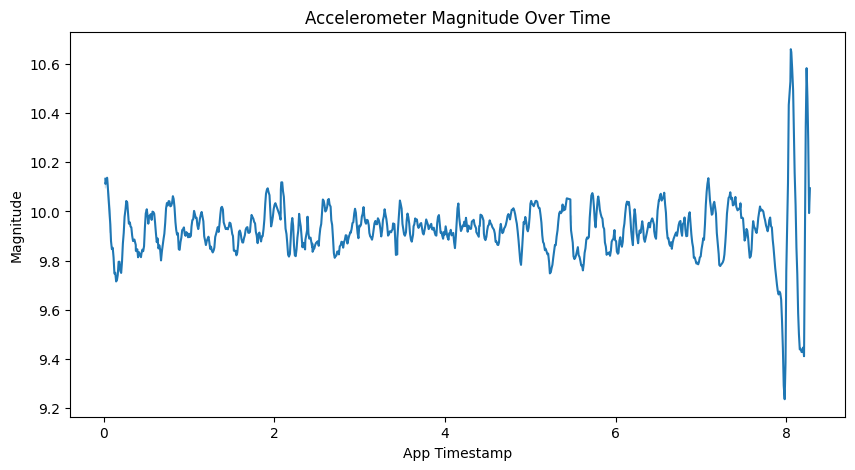

In [131]:
# Plot accelerometer magnitude over time
plt.figure(figsize=(10,5))
sns.lineplot(data=acc_df, x='app_ts', y='magnitude')
plt.title("Accelerometer Magnitude Over Time")
plt.xlabel("App Timestamp")
plt.ylabel("Magnitude")
plt.show()


Text(0.5, 0.92, 'Accelerometer 3D')

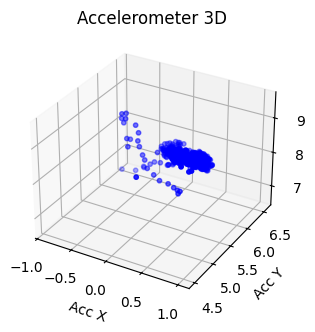

In [132]:
# ========================
# Accelerometer 3D Plot
# ========================
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(131, projection='3d')
ax.scatter(acc_df['x'], acc_df['y'], acc_df['z'], c='blue', s=10)
ax.set_xlabel('Acc X')
ax.set_ylabel('Acc Y')
ax.set_zlabel('Acc Z')
ax.set_title('Accelerometer 3D')

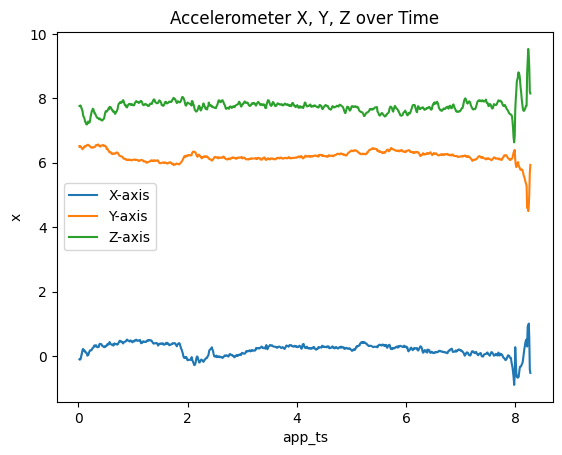

In [133]:
sns.lineplot(data=acc_df, x='app_ts', y='x', label='X-axis')
sns.lineplot(data=acc_df, x='app_ts', y='y', label='Y-axis')
sns.lineplot(data=acc_df, x='app_ts', y='z', label='Z-axis')
plt.title("Accelerometer X, Y, Z over Time")
plt.show()

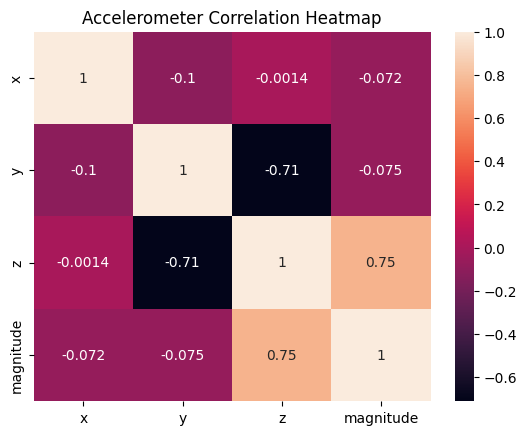

In [134]:
sns.heatmap(acc_df[['x','y','z','magnitude']].corr(), annot=True)
plt.title("Accelerometer Correlation Heatmap")
plt.show()


In [135]:
# Calculate mean and std from the DataFrame
mean_val = acc_df['magnitude'].mean()
std_val = acc_df['magnitude'].std()

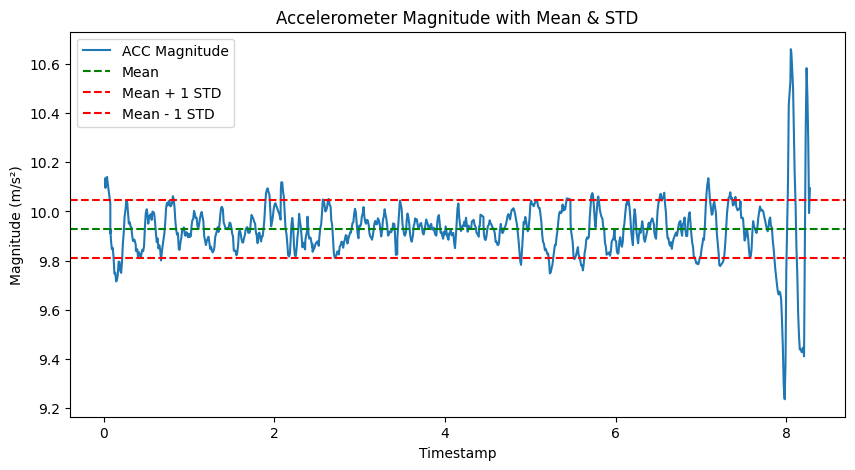

In [136]:
plt.figure(figsize=(10,5))
plt.plot(acc_df['app_ts'], acc_df['magnitude'], label='ACC Magnitude')
plt.axhline(mean_val, color='green', linestyle='--', label='Mean')
plt.axhline(mean_val + std_val, color='red', linestyle='--', label='Mean + 1 STD')
plt.axhline(mean_val - std_val, color='red', linestyle='--', label='Mean - 1 STD')
plt.title("Accelerometer Magnitude with Mean & STD")
plt.xlabel("Timestamp")
plt.ylabel("Magnitude (m/s²)")
plt.legend()
plt.show()

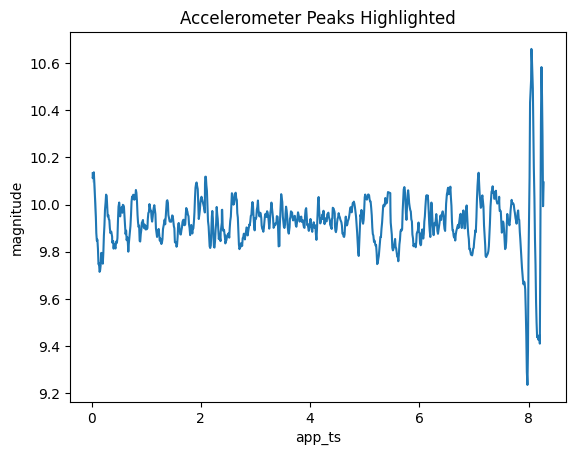

In [137]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(acc_df['magnitude'], height=12)
sns.lineplot(data=acc_df, x='app_ts', y='magnitude')
plt.scatter(acc_df['app_ts'].iloc[peaks], acc_df['magnitude'].iloc[peaks], color='red')
plt.title("Accelerometer Peaks Highlighted")
plt.show()


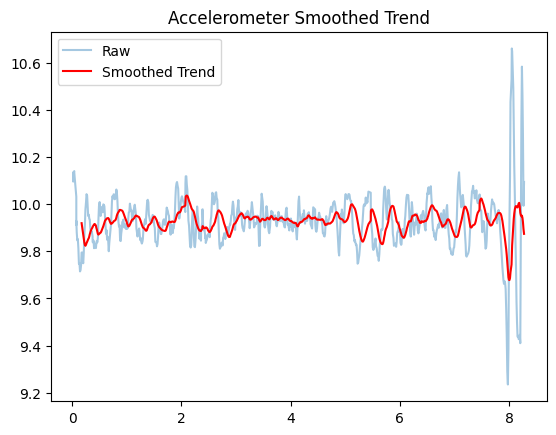

In [168]:

acc_df['rolling_mean'] = acc_df['magnitude'].rolling(window=20).mean()
plt.plot(acc_df['app_ts'], acc_df['magnitude'], alpha=0.4, label='Raw')
plt.plot(acc_df['app_ts'], acc_df['rolling_mean'], color='red', label='Smoothed Trend')
plt.legend()
plt.title("Accelerometer Smoothed Trend")
plt.show()


/tmp/ipython-input-2026906969.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([acc_df['x'], acc_df['y'], acc_df['z']], labels=['X', 'Y', 'Z'])


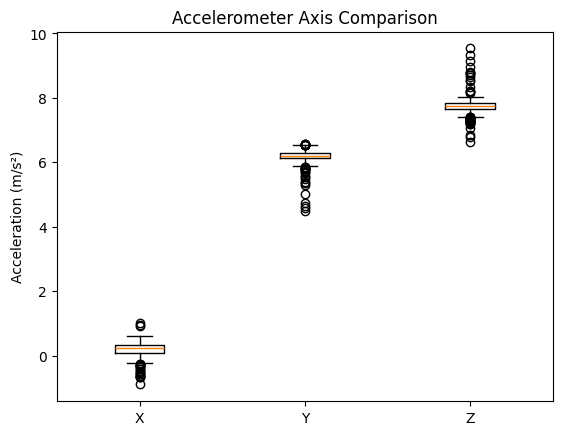

In [169]:

plt.boxplot([acc_df['x'], acc_df['y'], acc_df['z']], labels=['X', 'Y', 'Z'])
plt.title("Accelerometer Axis Comparison")
plt.ylabel("Acceleration (m/s²)")
plt.show()

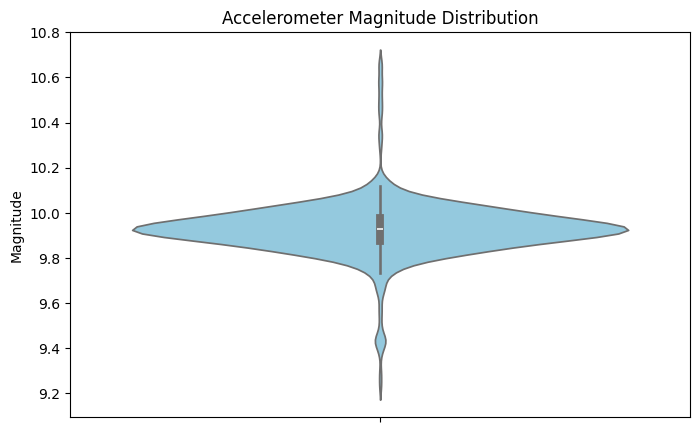

In [170]:
#  Violen plot Accelerometer
plt.figure(figsize=(8,5))
sns.violinplot(y=acc_df['magnitude'], color='skyblue')
plt.title("Accelerometer Magnitude Distribution")
plt.ylabel("Magnitude")
plt.show()

<b>3. Gyroscope Analysis</b>

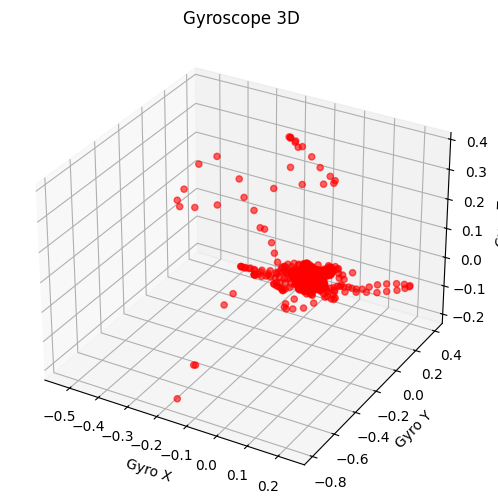

In [167]:
# ========================
# Gyroscope 3D Plot
# ========================
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(gyro_df['x'], gyro_df['y'], gyro_df['z'], c='red', s=20, alpha=0.6)
ax.set_xlabel('Gyro X')
ax.set_ylabel('Gyro Y')
ax.set_zlabel('Gyro Z')
ax.set_title('Gyroscope 3D')
plt.show()

In [140]:
# Compute total rotation magnitude
gyro_df['rotation'] = (gyro_df['x']**2 + gyro_df['y']**2 + gyro_df['z']**2)**0.5
print(gyro_df['rotation'])

0      0.133071
1      0.100894
2      0.116714
3      0.187114
4      0.259167
         ...   
831    0.455397
832    0.698382
833    0.826304
834    0.649141
835    0.340236
Name: rotation, Length: 836, dtype: float64


In [141]:
# Basic statistics
print("Gyroscope Statistics:")
print(gyro_df['rotation'].describe())


Gyroscope Statistics:
count    836.000000
mean       0.071009
std        0.097663
min        0.003429
25%        0.024767
50%        0.038938
75%        0.065920
max        0.826304
Name: rotation, dtype: float64


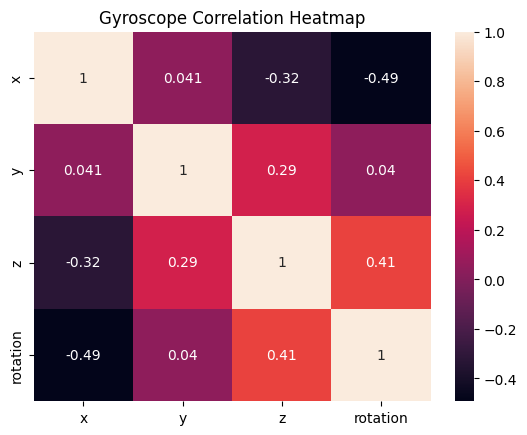

In [172]:

sns.heatmap(gyro_df[['x','y','z','rotation']].corr(), annot=True)
plt.title("Gyroscope Correlation Heatmap")
plt.show()

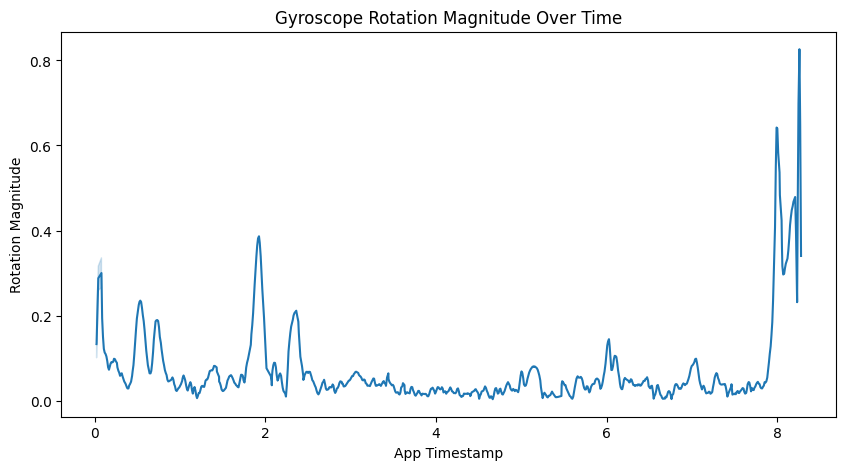

In [142]:
# Plot rotation over time
plt.figure(figsize=(10,5))
sns.lineplot(data=gyro_df, x='app_ts', y='rotation')
plt.title("Gyroscope Rotation Magnitude Over Time")
plt.xlabel("App Timestamp")
plt.ylabel("Rotation Magnitude")
plt.show()

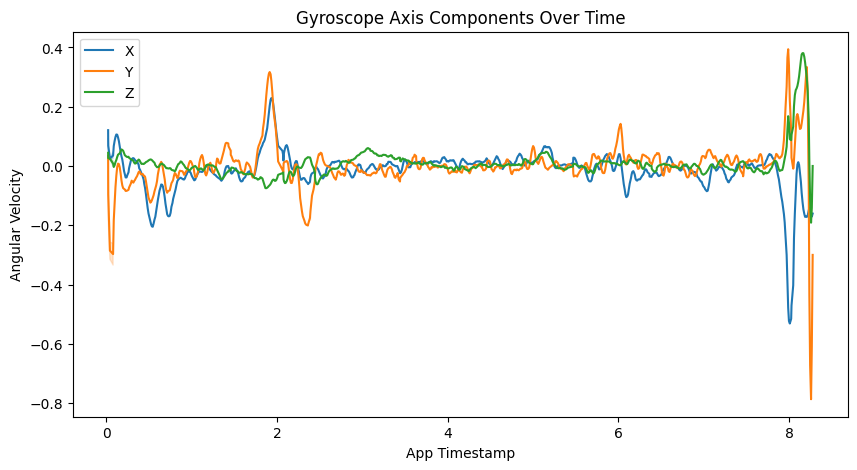

In [143]:
# Plot individual axis components
plt.figure(figsize=(10,5))
sns.lineplot(data=gyro_df, x='app_ts', y='x', label='X')
sns.lineplot(data=gyro_df, x='app_ts', y='y', label='Y')
sns.lineplot(data=gyro_df, x='app_ts', y='z', label='Z')
plt.title("Gyroscope Axis Components Over Time")
plt.xlabel("App Timestamp")
plt.ylabel("Angular Velocity")
plt.legend()
plt.show()

In [144]:
gyro_mean = gyro_df['rotation'].mean()
gyro_std = gyro_df['rotation'].std()

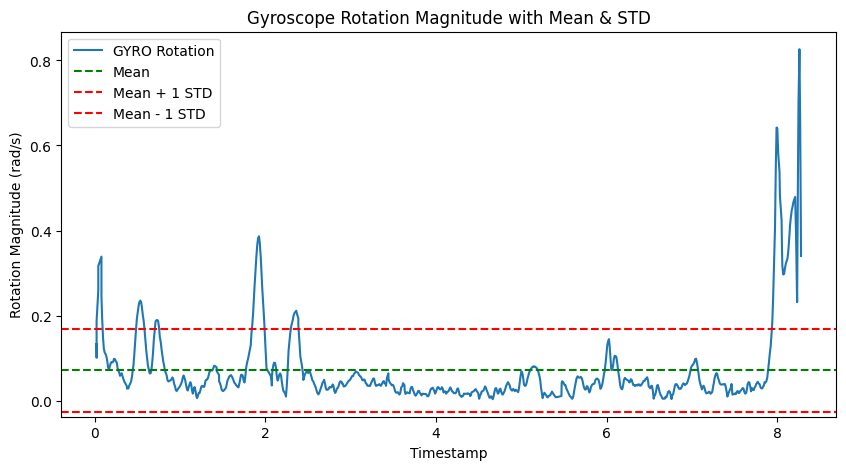

In [145]:

plt.figure(figsize=(10,5))
plt.plot(gyro_df['app_ts'], gyro_df['rotation'], label='GYRO Rotation')
plt.axhline(gyro_mean, color='green', linestyle='--', label='Mean')
plt.axhline(gyro_mean + gyro_std, color='red', linestyle='--', label='Mean + 1 STD')
plt.axhline(gyro_mean - gyro_std, color='red', linestyle='--', label='Mean - 1 STD')
plt.title("Gyroscope Rotation Magnitude with Mean & STD")
plt.xlabel("Timestamp")
plt.ylabel("Rotation Magnitude (rad/s)")
plt.legend()
plt.show()

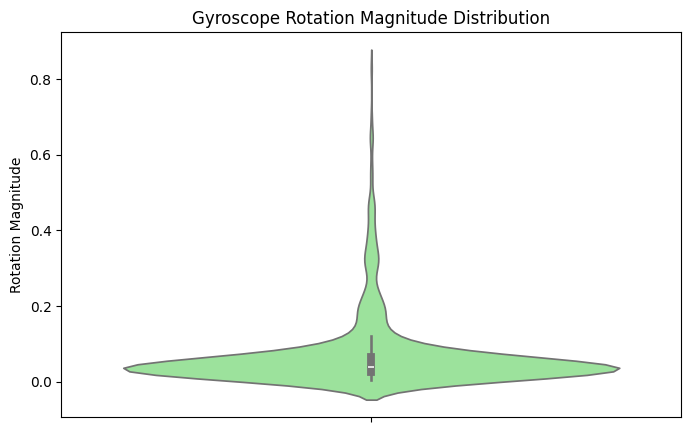

In [171]:
# Violen Plot
plt.figure(figsize=(8,5))
sns.violinplot(y=gyro_df['rotation'], color='lightgreen')
plt.title("Gyroscope Rotation Magnitude Distribution")
plt.ylabel("Rotation Magnitude")
plt.show()

/tmp/ipython-input-1095748614.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([gyro_df['x'], gyro_df['y'], gyro_df['z']], labels=['X', 'Y', 'Z'])


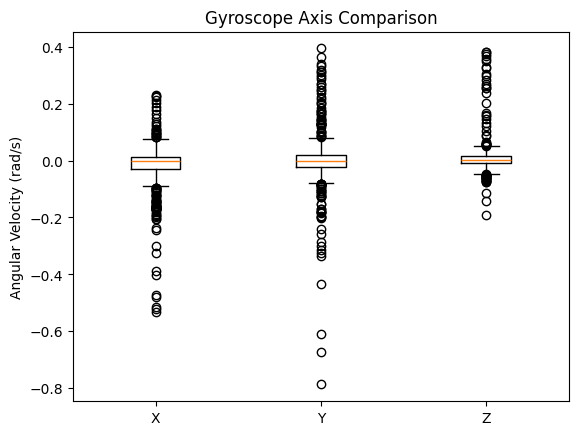

In [173]:
# Box plot
plt.boxplot([gyro_df['x'], gyro_df['y'], gyro_df['z']], labels=['X', 'Y', 'Z'])
plt.title("Gyroscope Axis Comparison")
plt.ylabel("Angular Velocity (rad/s)")  # or deg/s depending on your sensor unit
plt.show()

<b>4. Light Sensor Analysis<b>

In [146]:
# Basic statistics
print("Light Sensor Statistics:")
print(light_df['light'].describe())

Light Sensor Statistics:
count    24.000000
mean      0.416667
std       0.503610
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       1.000000
Name: light, dtype: float64


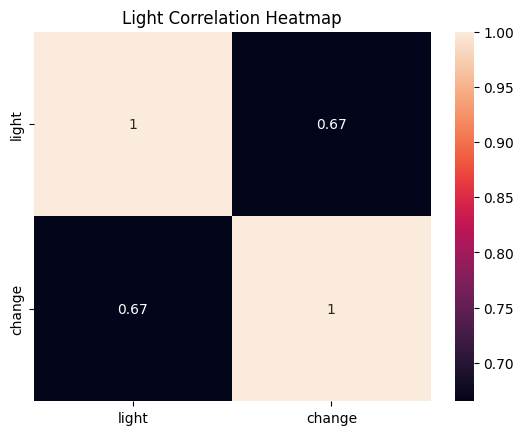

In [174]:

sns.heatmap(light_df[['light','change']].corr(), annot=True)
plt.title("Light Correlation Heatmap")
plt.show()


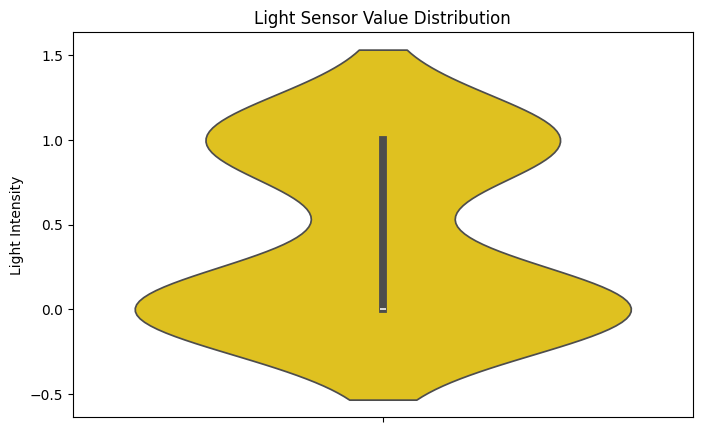

In [175]:

# Violen PLot
# Light Sensor
plt.figure(figsize=(8,5))
sns.violinplot(y=light_df['light'], color='gold')
plt.title("Light Sensor Value Distribution")
plt.ylabel("Light Intensity")
plt.show()


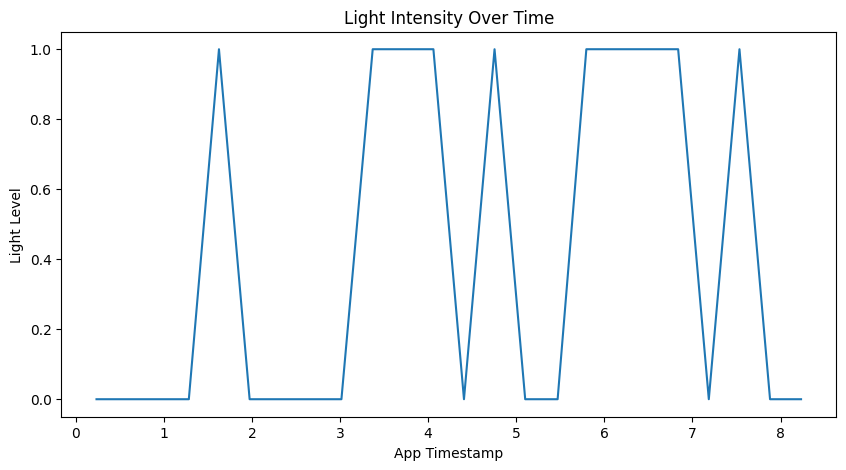

In [147]:
# Plot light intensity over time
plt.figure(figsize=(10,5))
sns.lineplot(data=light_df, x='app_ts', y='light')
plt.title("Light Intensity Over Time")
plt.xlabel("App Timestamp")
plt.ylabel("Light Level")
plt.show()

In [148]:
# Detect light changes or anomalies
light_df['change'] = light_df['light'].diff()

threshold = 1  # adjust as needed
anomalies = light_df[abs(light_df['change']) > threshold]

print(f"Detected {len(anomalies)} sudden light changes:")
print(anomalies[['app_ts','light','change']])



Detected 0 sudden light changes:
Empty DataFrame
Columns: [app_ts, light, change]
Index: []


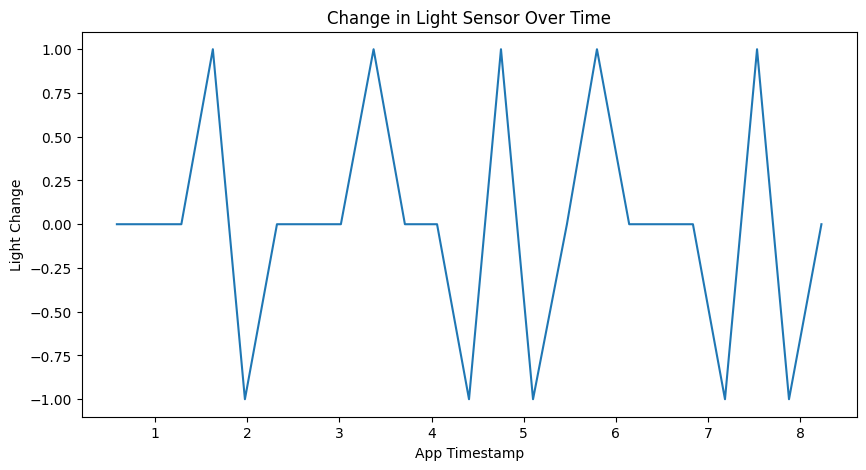

In [149]:
plt.figure(figsize=(10,5))
sns.lineplot(data=light_df, x='app_ts', y='change')
plt.title("Change in Light Sensor Over Time")
plt.xlabel("App Timestamp")
plt.ylabel("Light Change")
plt.show()


<b>5. Magnetometer Sensor Analysis<b>

In [150]:


# Calculate magnetic field magnitude
magn_df['mag_field'] = (magn_df['x']**2 + magn_df['y']**2 + magn_df['z']**2)**0.5

# Display statistical summary
print("Magnetometer Sensor Statistics:")
print(magn_df['mag_field'].describe())




Magnetometer Sensor Statistics:
count    836.000000
mean      44.110264
std        0.293488
min       43.199257
25%       43.902624
50%       44.111608
75%       44.302703
max       44.982809
Name: mag_field, dtype: float64


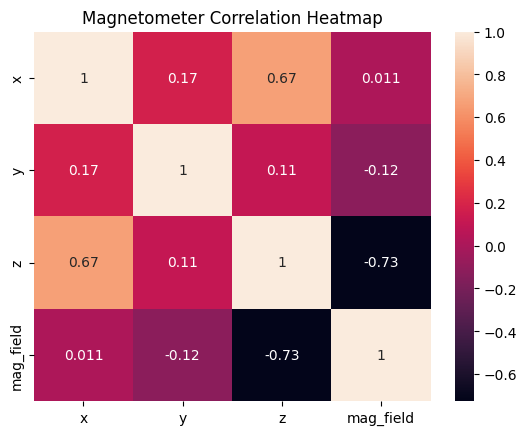

In [176]:
sns.heatmap(magn_df[['x','y','z','mag_field']].corr(), annot=True)
plt.title("Magnetometer Correlation Heatmap")
plt.show()

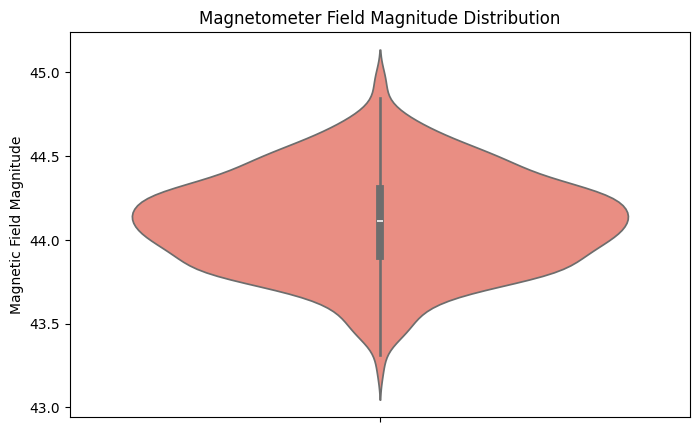

In [177]:

# Violen plot
plt.figure(figsize=(8,5))
sns.violinplot(y=magn_df['mag_field'], color='salmon')
plt.title("Magnetometer Field Magnitude Distribution")
plt.ylabel("Magnetic Field Magnitude")
plt.show()

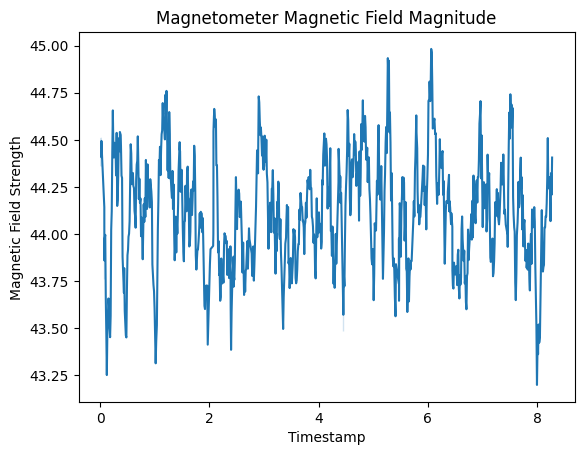

In [151]:
# Plot the magnetic field magnitude over time
sns.lineplot(data=magn_df, x='app_ts', y='mag_field').set(title="Magnetometer Magnetic Field Magnitude")
plt.xlabel("Timestamp")
plt.ylabel("Magnetic Field Strength")
plt.show()

In [152]:
magn_mean = magn_df['mag_field'].mean()
magn_std = magn_df['mag_field'].std()


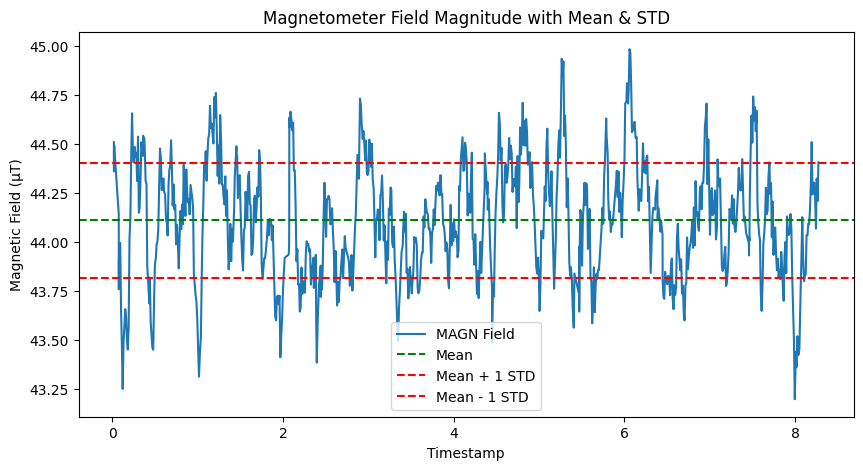

In [153]:

plt.figure(figsize=(10,5))
plt.plot(magn_df['app_ts'], magn_df['mag_field'], label='MAGN Field')
plt.axhline(magn_mean, color='green', linestyle='--', label='Mean')
plt.axhline(magn_mean + magn_std, color='red', linestyle='--', label='Mean + 1 STD')
plt.axhline(magn_mean - magn_std, color='red', linestyle='--', label='Mean - 1 STD')
plt.title("Magnetometer Field Magnitude with Mean & STD")
plt.xlabel("Timestamp")
plt.ylabel("Magnetic Field (μT)")
plt.legend()
plt.show()

/tmp/ipython-input-984507409.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([magn_df['x'], magn_df['y'], magn_df['z']], labels=['X', 'Y', 'Z'])


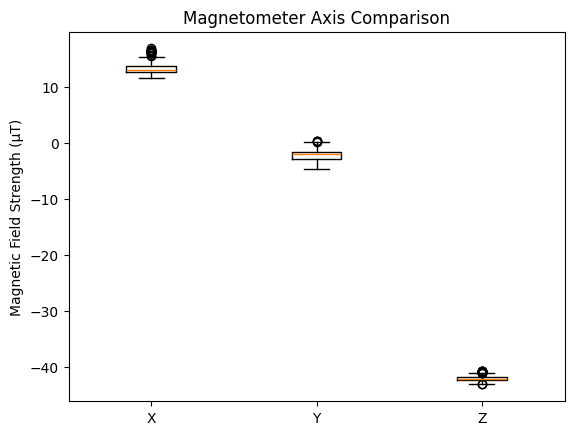

In [178]:

plt.boxplot([magn_df['x'], magn_df['y'], magn_df['z']], labels=['X', 'Y', 'Z'])
plt.title("Magnetometer Axis Comparison")
plt.ylabel("Magnetic Field Strength (µT)")  # microtesla or whatever unit your sensor uses
plt.show()

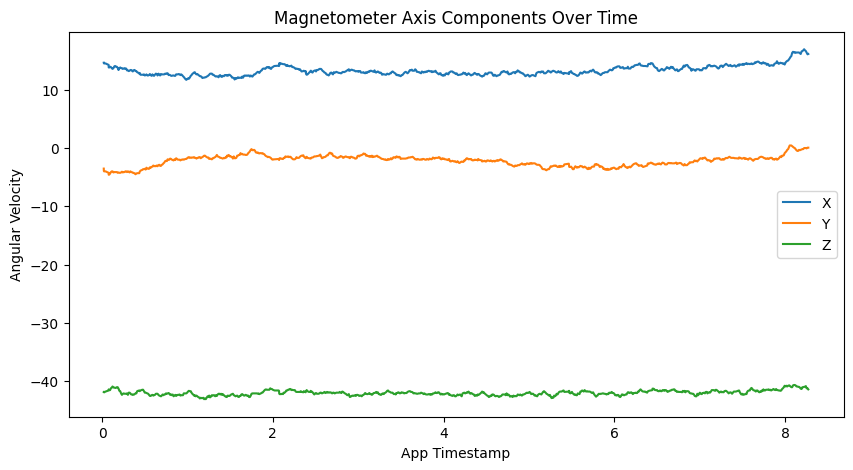

In [179]:

# Plot individual axis components
plt.figure(figsize=(10,5))
sns.lineplot(data=magn_df, x='app_ts', y='x', label='X')
sns.lineplot(data=magn_df, x='app_ts', y='y', label='Y')
sns.lineplot(data=magn_df, x='app_ts', y='z', label='Z')
plt.title("Magnetometer Axis Components Over Time")
plt.xlabel("App Timestamp")
plt.ylabel("Angular Velocity")
plt.legend()
plt.show()


<b>6. AHRS Sensor Analysis</b>


In [154]:
# Use the exact column names from CSV
ahrs_df['rot_magnitude'] = (ahrs_df['rotVecX']**2 + ahrs_df['rotVecY']**2 + ahrs_df['rotVecZ']**2)**0.5


In [155]:
# Basic stats
print("AHRS sensor Statistics")
print(ahrs_df['rot_magnitude'].describe())

AHRS sensor Statistics
count    417.000000
mean       0.387337
std        0.007906
min        0.372514
25%        0.381147
50%        0.386001
75%        0.393113
max        0.406350
Name: rot_magnitude, dtype: float64


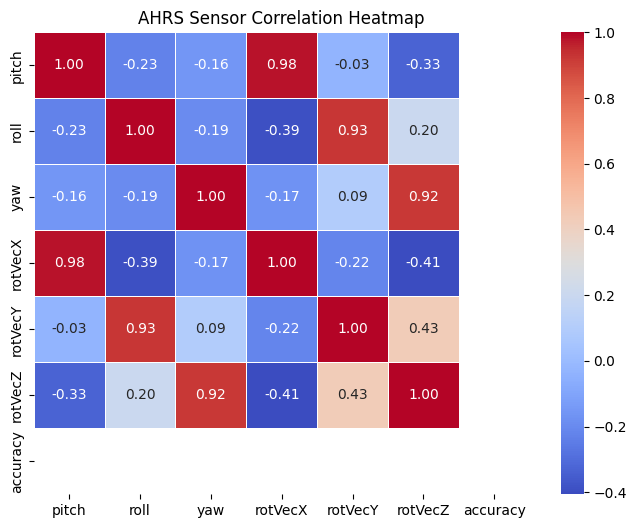

In [180]:

# Select relevant AHRS columns
ahrs_corr = ahrs_df[['pitch', 'roll', 'yaw', 'rotVecX', 'rotVecY', 'rotVecZ', 'accuracy']].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ahrs_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('AHRS Sensor Correlation Heatmap')
plt.show()

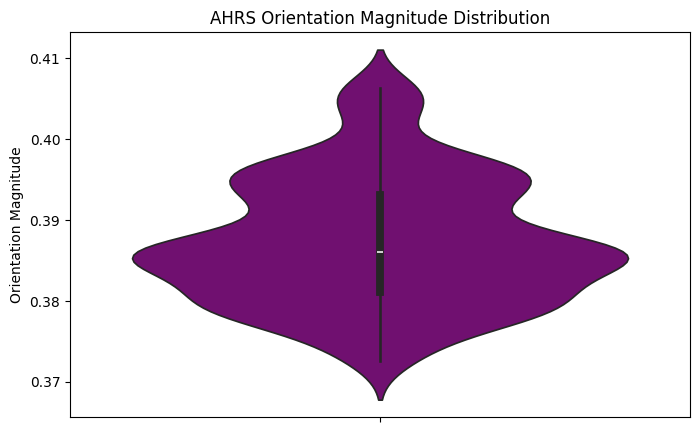

In [181]:

# Violen plot
plt.figure(figsize=(8,5))
sns.violinplot(y=ahrs_df['rot_magnitude'], color='purple')
plt.title("AHRS Orientation Magnitude Distribution")
plt.ylabel("Orientation Magnitude")
plt.show()

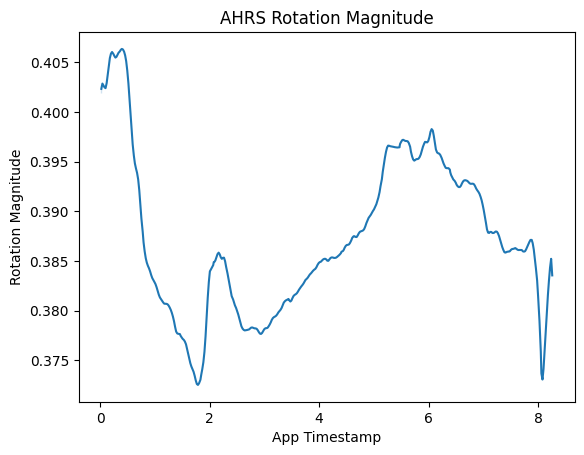

In [156]:
# Plot
sns.lineplot(data=ahrs_df, x='app_ts', y='rot_magnitude').set(title="AHRS Rotation Magnitude")
plt.xlabel("App Timestamp")
plt.ylabel("Rotation Magnitude")
plt.show()

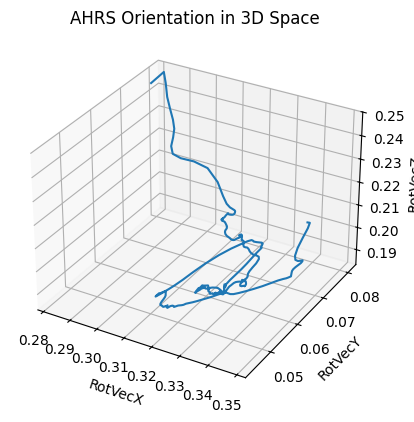

In [157]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(ahrs_df['rotVecX'], ahrs_df['rotVecY'], ahrs_df['rotVecZ'])
ax.set_xlabel('RotVecX')
ax.set_ylabel('RotVecY')
ax.set_zlabel('RotVecZ')
plt.title("AHRS Orientation in 3D Space")
plt.show()


In [158]:
import numpy as np
ahrs_df['orientation_mag'] = np.sqrt(ahrs_df['rotVecX']**2 + ahrs_df['rotVecY']**2 + ahrs_df['rotVecZ']**2)
ahrs_mean = ahrs_df['orientation_mag'].mean()
ahrs_std = ahrs_df['orientation_mag'].std()


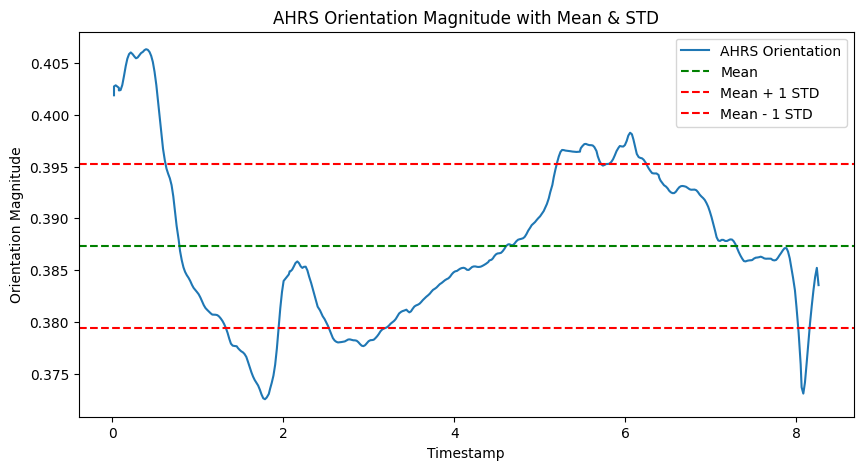

In [159]:

plt.figure(figsize=(10,5))
plt.plot(ahrs_df['app_ts'], ahrs_df['orientation_mag'], label='AHRS Orientation')
plt.axhline(ahrs_mean, color='green', linestyle='--', label='Mean')
plt.axhline(ahrs_mean + ahrs_std, color='red', linestyle='--', label='Mean + 1 STD')
plt.axhline(ahrs_mean - ahrs_std, color='red', linestyle='--', label='Mean - 1 STD')
plt.title("AHRS Orientation Magnitude with Mean & STD")
plt.xlabel("Timestamp")
plt.ylabel("Orientation Magnitude")
plt.legend()
plt.show()


###### Orientation Polar Plot
Represents how a device’s orientation changes.

Each point represents a moment in time.

- **Direction from the center** = yaw
- **Distance from the center** = pitch

| Pattern                        | Meaning                                                         |
| ------------------------------ | --------------------------------------------------------------- |
| **Points near the center**     | Device mostly level (small pitch).                              |
| **Points spread outward**      | Device tilted significantly.                                    |
| **Circular pattern**           | Smooth rotation with consistent tilt.                           |
| **Irregular or lobed shape**   | Uneven orientation — device rotated more in certain directions. |
| **Dense clusters in one area** | Device stayed in a specific orientation for a while.            |


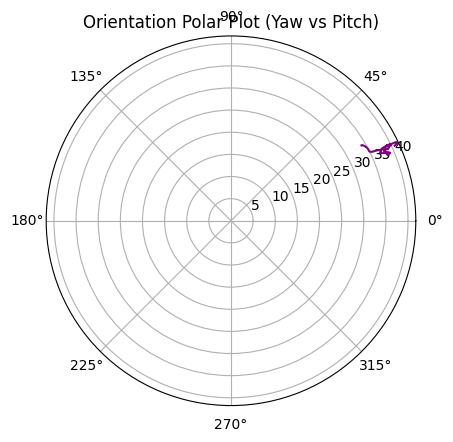

In [182]:
angles = np.deg2rad(ahrs_df['yaw'])
radii = np.abs(ahrs_df['pitch'])
plt.subplot(111, polar=True)
plt.plot(angles, radii, color='purple')
plt.title("Orientation Polar Plot (Yaw vs Pitch)")
plt.show()

<b>7. Sound Analysis</b>
<p>Shows fluctuations in sound levels over time.</p>

Peaks indicate loud sounds, valleys indicate quiet periods.

In [160]:
# Basic stats for Sound sensor
print("Sound Sensor Statistics:")

sound_df['intensity'] = sound_df['sound_level']

# Show descriptive statistics
print(sound_df['intensity'].describe())

Sound Sensor Statistics:
count    33.000000
mean      0.010411
std       0.009280
min       0.002930
25%       0.004350
50%       0.006230
75%       0.011360
max       0.034280
Name: intensity, dtype: float64


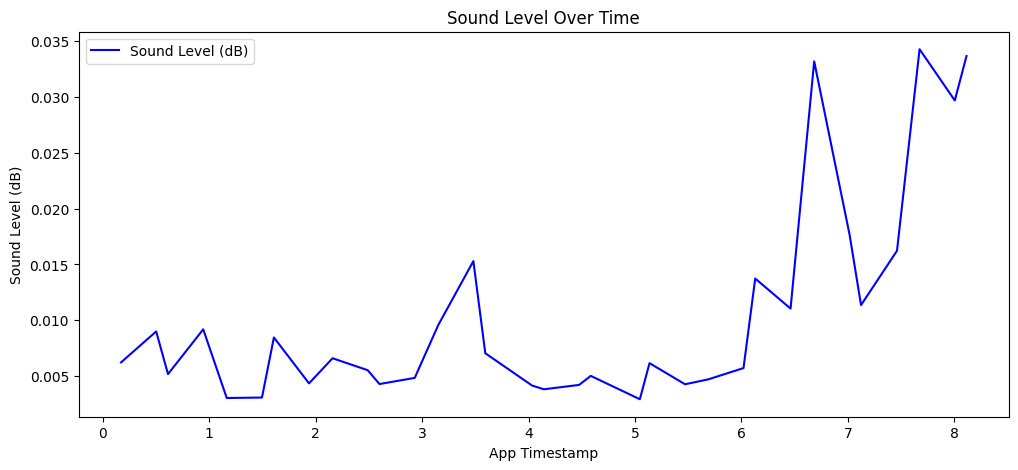

In [161]:
plt.figure(figsize=(12,5))
plt.plot(sound_df['app_ts'], sound_df['sound_level'], label='Sound Level (dB)', color='blue')
plt.xlabel('App Timestamp')
plt.ylabel('Sound Level (dB)')
plt.title('Sound Level Over Time')
plt.legend()
plt.show()


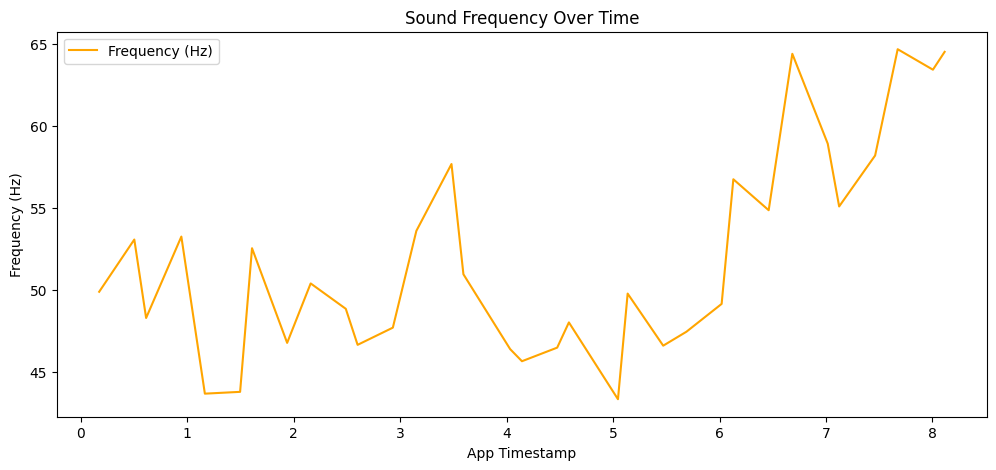

In [162]:
# sound frequency over time
# speech vs. environmental noise
plt.figure(figsize=(12,5))
plt.plot(sound_df['app_ts'], sound_df['frequency'], label='Frequency (Hz)', color='orange')
plt.xlabel('App Timestamp')
plt.ylabel('Frequency (Hz)')
plt.title('Sound Frequency Over Time')
plt.legend()
plt.show()

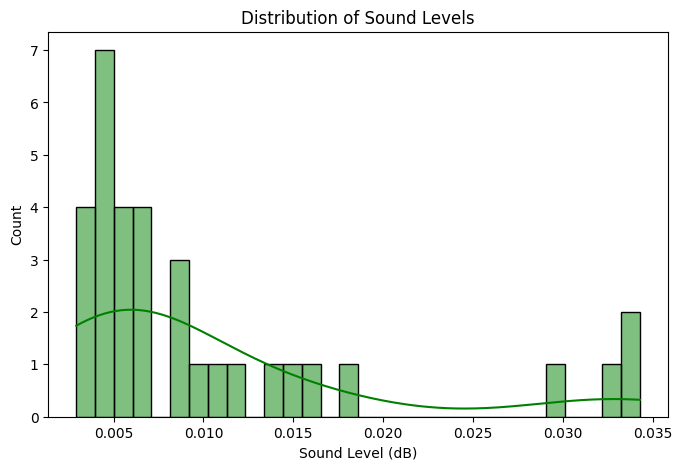

In [163]:
plt.figure(figsize=(8,5))
sns.histplot(sound_df['sound_level'], bins=30, kde=True, color='green')
plt.xlabel('Sound Level (dB)')
plt.title('Distribution of Sound Levels')
plt.show()


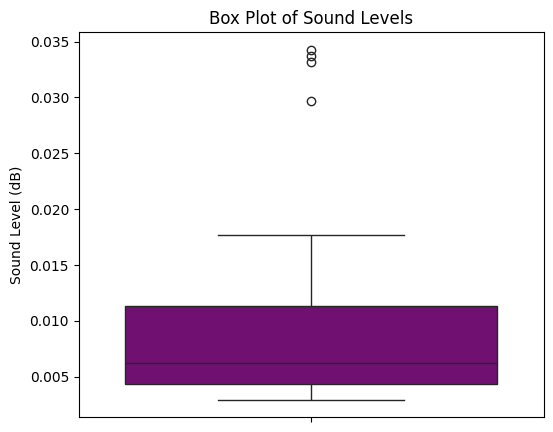

In [164]:
plt.figure(figsize=(6,5))
sns.boxplot(y=sound_df['sound_level'], color='purple')
plt.title('Box Plot of Sound Levels')
plt.ylabel('Sound Level (dB)')
plt.show()


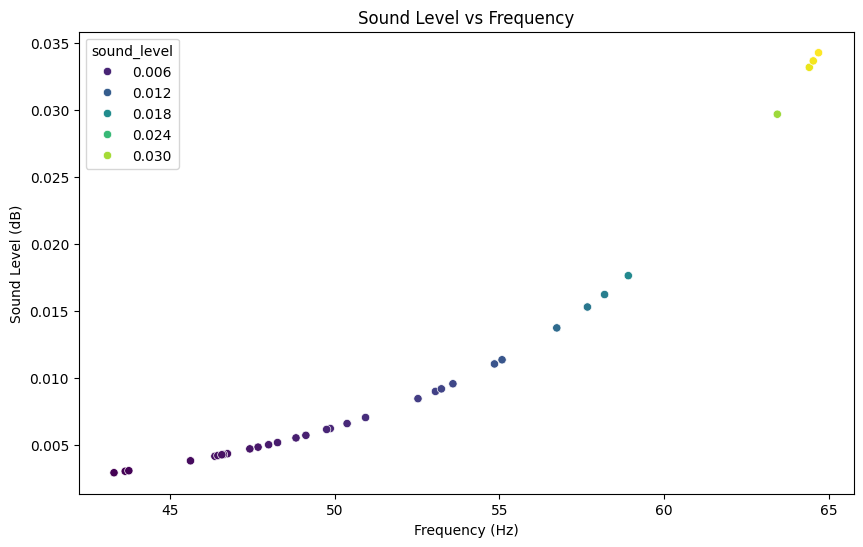

In [165]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='frequency', y='sound_level', data=sound_df, hue='sound_level', palette='viridis')
plt.title('Sound Level vs Frequency')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Sound Level (dB)')
plt.show()


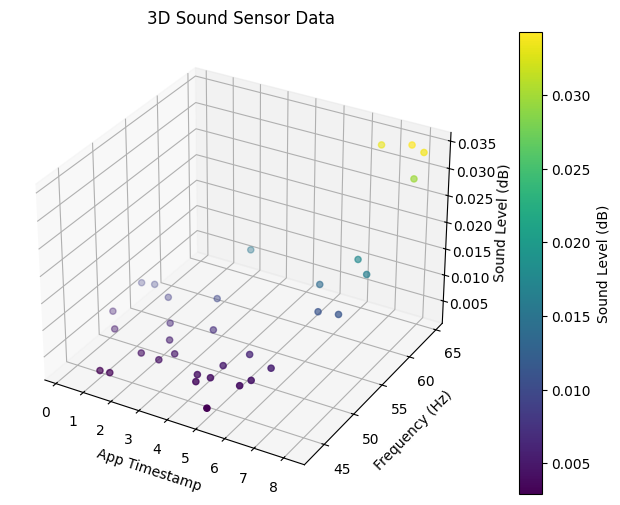

In [166]:


# Prepare data
x = sound_df['app_ts']        # Time
y = sound_df['frequency']     # Frequency (Hz)
z = sound_df['sound_level']   # Sound level (dB)

# Create 3D plot
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
sc = ax.scatter(x, y, z, c=z, cmap='viridis', s=20)  # Color by sound level

# Labels
ax.set_xlabel('App Timestamp')
ax.set_ylabel('Frequency (Hz)')
ax.set_zlabel('Sound Level (dB)')
ax.set_title('3D Sound Sensor Data')

# Color bar
plt.colorbar(sc, label='Sound Level (dB)')

plt.show()


## Combined Heat map:
1. “When the accelerometer magnitude increases, does the gyroscope magnitude also increase?”
2. “Is AHRS orientation affected by magnetic field changes?”

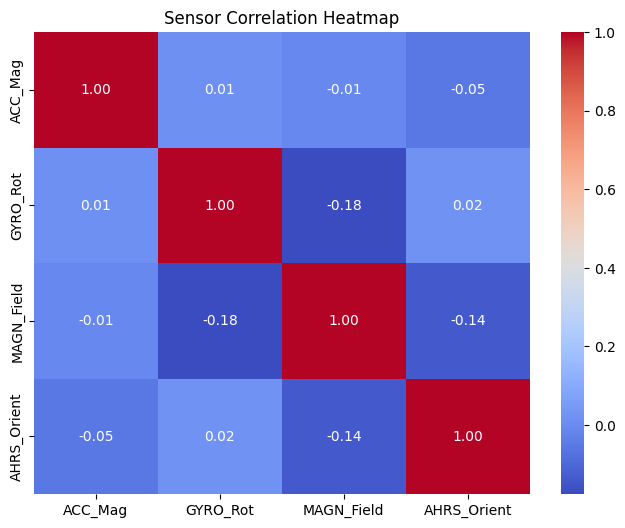

In [183]:
# Firstmagnitudes computed
acc_df['magnitude'] = np.sqrt(acc_df['x']**2 + acc_df['y']**2 + acc_df['z']**2)
gyro_df['rotation'] = np.sqrt(gyro_df['x']**2 + gyro_df['y']**2 + gyro_df['z']**2)
magn_df['mag_field'] = np.sqrt(magn_df['x']**2 + magn_df['y']**2 + magn_df['z']**2)
ahrs_df['orientation_mag'] = np.sqrt(ahrs_df['rotVecX']**2 + ahrs_df['rotVecY']**2 + ahrs_df['rotVecZ']**2)

# Combine all into a single DataFrame for correlation
combined_df = pd.DataFrame({
    'ACC_Mag': acc_df['magnitude'],
    'GYRO_Rot': gyro_df['rotation'],
    'MAGN_Field': magn_df['mag_field'],
    'AHRS_Orient': ahrs_df['orientation_mag']
})

# Compute correlation matrix
corr_matrix = combined_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Sensor Correlation Heatmap")
plt.show()



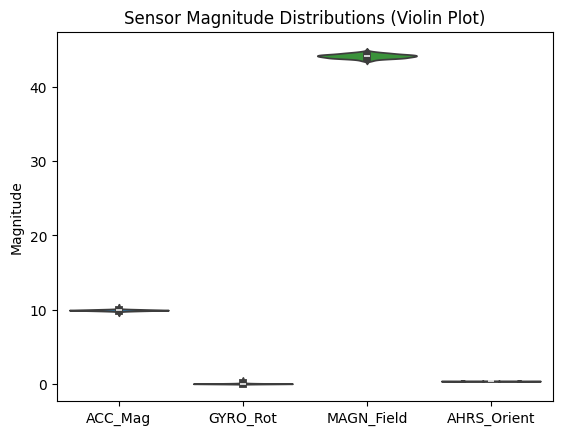

In [185]:
sns.violinplot(data=combined_df)
plt.title("Sensor Magnitude Distributions (Violin Plot)")
plt.ylabel("Magnitude")
plt.show()